# Graphics Card Market Analysis - Web Scraping Project

## Project Overview
In this project, you will create a web scraper to collect and analyze graphics card data from Newegg.com's GPU section. You'll use Python, BeautifulSoup, and other relevant libraries to extract key information about graphics cards currently available in the market.

## Learning Objectives
- Implement web scraping techniques using Python and BeautifulSoup
- Handle pagination in web scraping
- Process and structure collected data
- Practice working with real-world data
- Learn to respect website scraping policies and implement delays

## Part 1: Web scrapping
## Required Data to Extract
For each graphics card listing, you must collect:
1. Product Image URL
2. Product Title (e.g., "MSI Ventus GeForce RTX 3060 12GB")
3. Product Details:
   - Manufacturer
   - Model Number
   - Rating (number of stars)
5. Pricing Information:
   - Current Price
   - Original Price (if available)
   - Shipping Information

![Screenshot](image.png)

## Project Requirements

### Technical Requirements
1. Use Python 3.x
2. Required libraries:
   - requests
   - selenium
   - pandas
   - time (for implementing delays)

### Functional Requirements
1. Implement proper error handling
2. Include appropriate delays between requests (minimum 2 seconds)
3. Save the scraped data to a CSV file with appropriate column headers
4. Document your code with comments
5. Create a summary of the collected data (e.g., average price, price range)

## Part 2: Data Analysis
### Required Analysis

1. Price Analysis
   - Calculate average price by brand
   - Identify price ranges and market segments
   - Analyze price-to-memory ratio
   - Compare prices across different GPU series (RTX 3000 vs 4000)
   - Create price distribution visualizations

2. Brand Analysis
   - Market share by brand
   - Average ratings by brand
   - Price comparison across brands
   - Create brand comparison visualizations

3. Memory Configuration Analysis
   - Distribution of memory sizes
   - Price correlation with memory size
   - Popular memory configurations by brand

4. Market Segmentation
   - Entry-level vs Mid-range vs High-end segments
   - Price brackets and their features





## Deliverables
1. Python script containing the web scraper
2. CSV file with the collected data
3. README file explaining:
   - Project Description
   - Features
5. Short report analyzing the collected data

## Important Notes
- Always check and respect the website's robots.txt file
- Implement appropriate delays between requests to avoid overwhelming the server
- Handle your requests responsibly and ethically
- Be prepared to handle cases where data might be missing or in an unexpected format

In [34]:
#importing the necessary libraries and dependencies
import time

from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import Select, WebDriverWait
from webdriver_manager.chrome import ChromeDriverManager

import pandas as pd
import selenium
from selenium import webdriver

from tqdm import tqdm #to show progress bar

In [35]:
url = "https://www.newegg.com/Desktop-Graphics-Cards/SubCategory/ID-48"

PAGES_TO_SCRAPE = 20

#starting selenium
service = Service(ChromeDriverManager().install())
options = Options()
options.add_argument('--headless=new')
driver = webdriver.Chrome(options=options)
driver.get(url)
time.sleep(5)

gpus = []
page = 1

#setting a loop to scrape each page
while page <= PAGES_TO_SCRAPE:
    driver.get(url + '/Page-' + str(page)) #moves through pages via url
    products = driver.find_elements(By.CLASS_NAME, 'item-cell') #targets the div containing item details

#targets the desired information per div, with error handling if there's something missing
    for product in tqdm(products, f'Page {page} in progress...'):
        img = product.find_elements(By.CLASS_NAME, 'item-img')
        if img:
            img = img[0].find_element(By.TAG_NAME, 'img').get_attribute('src')
        else:
            img = None

        rating = product.find_elements(By.CLASS_NAME, 'item-rating')
        if rating:
            rating = rating[0].get_attribute('title').split('+ ', 1)[-1]
        else:
            rating = None

        reviews = product.find_elements(By.CLASS_NAME, 'item-rating-num')
        if reviews:
            reviews = reviews[0].text
        else:
            reviews = None

        manufacturer = product.find_elements(By.CLASS_NAME, 'item-brand')
        if manufacturer:
            manufacturer = manufacturer[0].find_element(By.TAG_NAME, 'img').get_attribute('title') or manufacturer[0].find_element(By.TAG_NAME, 'img').get_attribute('alt')
        else:
            manufacturer = None

        title = product.find_elements(By.CLASS_NAME, 'item-title')[0].text
        if not title:
            continue

        model = product.find_elements(By.CLASS_NAME, 'item-features')
        if model:
            model_raw = model[0].text
            model_text = model_raw.split(': ', 1)[-1]
        else:
            model_text = None

        price = product.find_elements(By.CLASS_NAME, 'price-current')
        if price:
            price = price[0].text
        else:
            price = None

        shipping_price = product.find_elements(By.CLASS_NAME, 'price-ship')
        if shipping_price:
            shipping_price = shipping_price[0].text
        else:
            shipping_price = None

        original_price = product.find_elements(By.CLASS_NAME, 'price-was')
        if original_price:
            original_price = original_price[0].text
        else:
            original_price = None

#writes the scraped information into an object to append into a list
        gpu = {
            'img': img,
            'rating': rating,
            'reviews': reviews,
            'manufacturer': manufacturer,
            'title': title,
            'model': model_text,
            'price': price,
            'shipping_price': shipping_price,
            'original_price': original_price
        }
        gpus.append(gpu)

    page+=1

time.sleep(3)
driver.quit()

#saves the data into a .csv file
df = pd.DataFrame(gpus)
df.to_csv('newegg.csv', index=False)

Page 20 in progress...: 100%|███████████████████████████████████████████████████████████| 36/36 [00:01<00:00, 26.94it/s]


## Part 2: Data Analysis

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Load the dataset
df = pd.read_csv('newegg.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()
df.isnull().sum()

Dataset loaded: 720 rows, 9 columns


img                 0
rating            261
reviews           261
manufacturer      115
title               0
model               0
price               1
shipping_price     43
original_price    569
dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   img             720 non-null    object 
 1   rating          459 non-null    float64
 2   reviews         459 non-null    object 
 3   manufacturer    605 non-null    object 
 4   title           720 non-null    object 
 5   model           720 non-null    object 
 6   price           719 non-null    object 
 7   shipping_price  677 non-null    object 
 8   original_price  151 non-null    object 
dtypes: float64(1), object(8)
memory usage: 50.8+ KB


### Data cleaning

In [38]:
# shipping_price: "Free Shipping" -> 0, "$19.99 Shipping" -> 19.99
df['shipping_price'] = (
    df['shipping_price']
    .replace('Free Shipping', '0')
    .astype(str)
    .str.replace(r'[\$]|\sShipping', '', regex=True)
)
df['shipping_price'] = pd.to_numeric(df['shipping_price'], errors='coerce')
print(df['shipping_price'].dtype)

float64


In [40]:
# reviews: "(124)" -> 124, "(1,017)" -> 1017
df['reviews'] = df['reviews'].astype(str).str.replace(r'[(),]', '', regex=True)
df['reviews'] = pd.to_numeric(df['reviews'], errors='coerce').astype('Int64')

In [41]:
# price, strip dollar sign
df['price'] = df['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [42]:
# original_price: "$1,271.99" -> 1271.99
df['original_price'] = df['original_price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df['original_price'] = pd.to_numeric(df['original_price'], errors='coerce')

In [46]:
# fill nulls
# fills where original price is null but price is present
df['original_price'] = df['original_price'].fillna(df['price'])

# fills the cell where price is null but original price is present
df['price'] = df['price'].fillna(df['original_price'])

# drops rows where there is no original price nor price
df = df.dropna(subset=['price', 'original_price'], how='all')

# fills appropriate values for null
df['shipping_price'] = df['shipping_price'].fillna(0)
df['rating'] = df['rating'].fillna(0)
df['reviews'] = df['reviews'].fillna(0)
df['manufacturer'] = df['manufacturer'].fillna('Unknown')

In [45]:
df.to_csv('newegg_clean_filled.csv', index=False)

In [55]:
df.isnull().sum() #verify data cleaning results
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 719 entries, 0 to 719
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   img             719 non-null    object 
 1   rating          719 non-null    float64
 2   reviews         719 non-null    Int64  
 3   manufacturer    719 non-null    object 
 4   title           719 non-null    object 
 5   model           719 non-null    object 
 6   price           719 non-null    float64
 7   shipping_price  719 non-null    float64
 8   original_price  719 non-null    float64
 9   memory          715 non-null    float64
dtypes: Int64(1), float64(5), object(4)
memory usage: 62.5+ KB


### Data analysis

1. **Price Analysis**
   - **Calculate average price by brand**
   - **Identify price ranges and market segments**
   - **Analyze price-to-memory ratio**
   - **Compare prices across different GPU series (RTX 3000 vs 4000)**
   - **Create price distribution visualizations**


In [48]:
df.head()

,img,rating,reviews,manufacturer,title,model,price,shipping_price,original_price
0,https://c1.neweggimages.com/productimage/nb300...,4.7,125,Sapphire Tech,SAPPHIRE PULSE Radeon RX 9060 XT 16GB GDDR6 PC...,11350-03-20G,499.99,0.0,499.99
1,https://c1.neweggimages.com/productimage/nb300...,4.7,111,ASRock,ASRock Challenger Radeon RX 9060 XT 16GB GDDR6...,RX9060XT CL 16GO,469.99,0.0,498.49
2,https://c1.neweggimages.com/productimage/nb300...,4.8,241,GIGABYTE,GIGABYTE Gaming GeForce RTX 5070 Ti 16GB GDDR7...,GV-N507TGAMING OC-16GD,1087.99,0.0,1271.99
3,https://c1.neweggimages.com/productimage/nb300...,4.6,139,ASRock,ASRock Challenger Radeon RX 9070 XT 16GB GDDR6...,RX9070XT CL 16G,719.99,0.0,719.99
4,https://c1.neweggimages.com/productimage/nb300...,4.6,299,GIGABYTE,GIGABYTE Gaming GeForce RTX 5080 16GB GDDR7 PC...,GV-N5080GAMING OC-16GD,1699.99,0.0,1699.99


In [105]:
# average price by brand
df['price'] = pd.to_numeric(df['price'])
avg_price_by_brand = df.groupby(['manufacturer'])['price'].mean()
print(avg_price_by_brand)
print(avg_price_by_brand.min())
print(avg_price_by_brand.max())

manufacturer
AMD               304.325000
ASRock            470.875000
ASUS             1205.040329
GIGABYTE          918.080078
HP                809.000000
Intel             590.000000
Lenovo            233.706000
MSI               838.578053
NVIDIA           1251.741818
PowerColor        673.690000
Sapphire Tech     805.931143
Unknown           521.814261
XFX               572.719091
ZOTAC            1175.789091
Name: price, dtype: float64
233.706
1251.7418181818182


In [51]:
df.to_csv('newegg_clean_filled.csv', index=False)

<Axes: xlabel='price', ylabel='Count'>

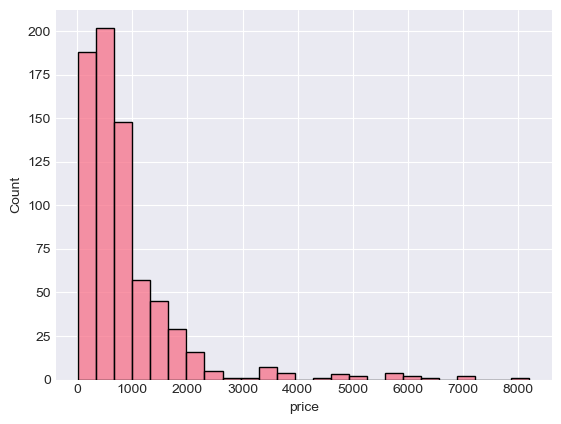

In [106]:
#Identify price ranges and market segments
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df, x= 'price', bins=25)

### From the histogram we can see that GPU prices are highly concentrated roughly in the `$`250-`$`500 area (from dividing this into 25 bins)
-- the average prices per brand shows average values range from 236 to 1169.

In [53]:
#extracting the memory value from title
df['memory'] = df['title'].str.extract(r'(\d+)\s?G')[0]

/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_22856/1066478990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['memory'] = df['title'].str.extract(r'(\d+)\s?G')[0]


In [54]:
#converting to numeric
df['memory'] = pd.to_numeric(df['memory'])

/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_22856/599472742.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['memory'] = pd.to_numeric(df['memory'])


In [56]:
df.groupby(['memory'])['price'].sum()

memory
1.0          3087.95
2.0          4275.76
3.0          1356.53
4.0         12362.70
6.0          8431.03
8.0         70558.91
10.0         7812.47
11.0         3644.00
12.0        70781.28
16.0       245338.35
20.0        11203.95
24.0        76403.12
32.0        84884.10
40.0          845.98
48.0         8199.00
90.0          159.99
100.0         667.98
200.0          65.00
400.0         222.80
470.0         164.22
510.0          85.00
550.0         104.99
620.0          18.74
710.0         133.48
750.0         209.99
1030.0        119.95
3050.0        399.99
3060.0        977.99
3090.0       1899.00
4070.0       1539.98
4080.0       1543.27
5000.0        845.00
5060.0        459.99
5070.0       3054.00
6000.0       1399.00
7900.0       1095.00
7970.0        159.99
8400.0         39.99
8600.0        275.00
9070.0       4359.24
9400.0        149.00
10700.0       279.00
Name: price, dtype: float64

From the above sum, we could see that our regex is not extracting the appropriate memory, we need to clean up our regex

In [57]:
# extracts memory size from titles
df['memory'] = df['title'].str.extract(r'(\d+)\s?G(?:B)?\b')[0]
df['memory'] = pd.to_numeric(df['memory'])

/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_22856/137230985.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['memory'] = df['title'].str.extract(r'(\d+)\s?G(?:B)?\b')[0]
/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_22856/137230985.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['memory'] = pd.to_numeric(df['memory'])


In [58]:
df.groupby(['memory'])['price'].value_counts()

memory   price  
1.0      65.00      2
         18.74      1
         22.99      1
         39.99      1
         44.99      1
                   ..
32.0     6900.00    1
         6999.00    1
48.0     8199.00    1
90.0     159.99     1
10700.0  279.00     1
Name: count, Length: 524, dtype: int64

In [59]:
df['memory'].value_counts()

memory
16.0       215
8.0        163
12.0       109
4.0         49
24.0        38
2.0         33
6.0         30
32.0        16
10.0        14
1.0         11
20.0        10
11.0         9
3.0          5
5.0          2
90.0         1
48.0         1
10700.0      1
Name: count, dtype: int64

Preliminary cleaning this data reveals that we have two outliers, 90GB and 10700GB graphic cards with price that seems unrealistic.
Double checking it shows that our regex could not parse two rows cleanly and so we have to manually set the memory based on the model's actual specs.

In [60]:
df.loc[df['title'] == "ZOTAC GeForce GTX 1070 Mini, ZT-P10700G-10M, 8GB GDDR5", "memory"] = 8
df.loc[df['title'] == "REFURBISHED SAPPHIRE NITRO+ Radeon RX 5700 XT DirectX 12 11293-97-90G Video Card", "memory"] = 8

In [61]:
df.to_csv('newegg_clean_corrected.csv', index=False)

In [62]:
#calculating price per memory unit
df['price_per_gb'] = df['price']/df['memory']
df['price_per_gb'].mean()

/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_22856/1845813569.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_per_gb'] = df['price']/df['memory']


np.float64(66.67523723533067)

In [63]:
import re

pattern = r'\b(RTX|RX)\s?(\d{3,4})'

def extract_series(title):
    match = re.search(pattern, title)
    if match:
        prefix = match.group(1).upper()
        digits = match.group(2)
        return f'{prefix} {digits}'
    return 'Other'

df['series'] = df['title'].apply(extract_series)

print(df['series'].value_counts())

series
Other       167
RTX 5070     61
RX 9070      57
RTX 5060     56
RTX 4070     39
RTX 5080     37
RTX 3060     28
RX 9060      23
RX 7900      21
RTX 3080     20
RTX 4080     19
RTX 4060     17
RTX 3050     15
RTX 5090     14
RTX 3070     14
RX 6600      13
RTX 3090     11
RTX 4090     10
RX 5700       8
RTX 2080      7
RX 580        7
RX 6700       6
RTX 2060      6
RX 7800       6
RX 6900       5
RTX 2070      4
RX 6400       4
RX 6500       4
RX 550        4
RX 7700       4
RTX 5050      4
RX 5500       4
RX 6800       3
RTX 5000      3
RX 7600       3
RX 570        3
RX 470        2
RX 6950       2
RTX 4000      1
RTX 6000      1
RTX 2000      1
RX 6650       1
RX 5600       1
RX 460        1
RX 6750       1
RX 590        1
Name: count, dtype: int64


/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_22856/2649698389.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['series'] = df['title'].apply(extract_series)


In [64]:
df.groupby(['series'])['price'].mean()

series
Other        309.052096
RTX 2000     999.000000
RTX 2060     547.916667
RTX 2070     450.000000
RTX 2080     665.855714
RTX 3050     308.608667
RTX 3060     519.647500
RTX 3070     513.521429
RTX 3080     598.668500
RTX 3090    2011.090000
RTX 4000    2250.000000
RTX 4060     531.407059
RTX 4070    1031.096667
RTX 4080    1578.926842
RTX 4090    3566.099000
RTX 5000    2091.333333
RTX 5050     352.490000
RTX 5060     650.455714
RTX 5070    1139.117049
RTX 5080    1973.818108
RTX 5090    5736.007143
RTX 6000    8199.000000
RX 460        99.990000
RX 470       112.105000
RX 550        97.247500
RX 5500      252.750000
RX 5600      365.550000
RX 570       211.326667
RX 5700      378.372500
RX 580       203.947143
RX 590       166.000000
RX 6400      301.882500
RX 6500      224.580000
RX 6600      453.575385
RX 6650      448.020000
RX 6700      533.328333
RX 6750      549.990000
RX 6800      456.160000
RX 6900      457.990000
RX 6950      459.990000
RX 7600      346.656667
RX 7700  

In [65]:
def extract_generation(series):
    match = re.match(r'(RTX|RX)\s(\d+)', series)
    if match:
        prefix, digits = match.groups()
        if len(digits) == 4:
            gen = digits[0] + '000'
        elif len(digits) == 3:
            gen = digits[0] + '00'
        else:
            return 'Other'
        return f'{prefix} {gen}'
    return 'Other'

df['generation'] = df['series'].apply(extract_generation)

print(df['generation'].value_counts())

generation
RTX 5000    175
Other       167
RTX 3000     88
RTX 4000     86
RX 9000      80
RX 6000      39
RX 7000      34
RTX 2000     18
RX 500       15
RX 5000      13
RX 400        3
RTX 6000      1
Name: count, dtype: int64


/var/folders/1r/ztpj74kn6cb720hjkspx3l1w0000gn/T/ipykernel_22856/3949104376.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['generation'] = df['series'].apply(extract_generation)


In [66]:
 df.groupby(['generation','series'])['price'].agg(['mean','median'])

mean    median
generation series                         
Other      Other      309.052096   245.000
RTX 2000   RTX 2000   999.000000   999.000
           RTX 2060   547.916667   579.000
           RTX 2070   450.000000   425.000
           RTX 2080   665.855714   699.000
RTX 3000   RTX 3050   308.608667   289.590
           RTX 3060   519.647500   498.475
           RTX 3070   513.521429   472.245
           RTX 3080   598.668500   554.990
           RTX 3090  2011.090000  2099.000
RTX 4000   RTX 4000  2250.000000  2250.000
           RTX 4060   531.407059   542.000
           RTX 4070  1031.096667  1001.040
           RTX 4080  1578.926842  1610.000
           RTX 4090  3566.099000  3532.000
RTX 5000   RTX 5000  2091.333333   849.000
           RTX 5050   352.490000   322.490
           RTX 5060   650.455714   545.445
           RTX 5070  1139.117049  1119.990
           RTX 5080  1973.818108  1799.990
           RTX 5090  5736.007143  5813.590
RTX 6000   RTX 6000  8199.000000  8199.000
RX 400     RX 460      99.990000    99.990
           RX 470     112.105000   112.105
RX 500     RX 550      97.247500   101.995
           RX 570     211.326667   144.990
           RX 580     203.947143   139.850
           RX 590     166.000000   166.000
RX 5000    RX 5500    252.750000   185.500
           RX 5600    365.550000   365.550
           RX 5700    378.372500   299.000
RX 6000    RX 6400    301.882500   315.265
           RX 6500    224.580000   215.165
           RX 6600    453.575385   449.000
           RX 6650    448.020000   448.020
           RX 6700    533.328333   531.995
           RX 6750    549.990000   549.990
           RX 6800    456.160000   469.000
           RX 6900    457.990000   449.990
           RX 6950    459.990000   459.990
RX 7000    RX 7600    346.656667   339.990
           RX 7700    564.082500   557.070
           RX 7800    743.806667   759.990
           RX 7900   1144.433810  1215.000
RX 9000    RX 9060    551.954783   529.990
           RX 9070    826.438421   789.990

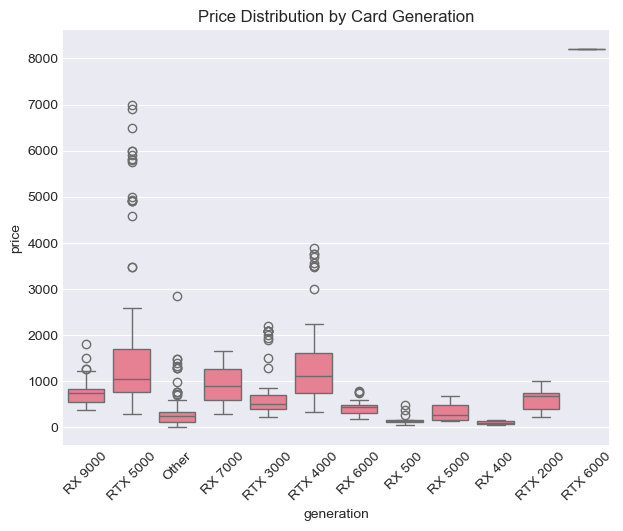

In [107]:
sns.boxplot(data=df,x='generation',y='price')
plt.tight_layout()
plt.title('Price Distribution by Card Generation')
plt.xticks(rotation=45)
plt.show()

2. **Brand Analysis**
   - **Market share by brand**
   - **Average ratings by brand**
   - **Price comparison across brands**
   - **Create brand comparison visualizations**

manufacturer
ASUS             21.140473
GIGABYTE         17.941586
Unknown          15.994437
MSI              15.716273
NVIDIA            6.119611
Sapphire Tech     4.867872
XFX               4.589708
ZOTAC             4.589708
ASRock            4.172462
PowerColor        2.920723
AMD               0.834492
Lenovo            0.695410
HP                0.278164
Intel             0.139082
Name: count, dtype: float64


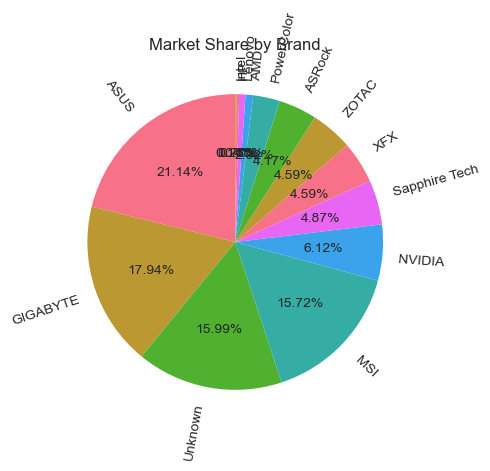

In [112]:
#market share by brand
brand_share = df['manufacturer'].value_counts()/len(df) * 100
print(brand_share)
plt.pie(brand_share, labels=brand_share.index, autopct='%.2f%%', startangle=90, rotatelabels=True)
plt.title('Market Share by Brand')
plt.show()

In [69]:
#average rating by brand
df.groupby(['manufacturer'])['rating'].mean()

manufacturer
AMD              2.500000
ASRock           3.196667
ASUS             2.627632
GIGABYTE         3.738760
HP               0.000000
Intel            0.000000
Lenovo           1.000000
MSI              3.953982
NVIDIA           1.613636
PowerColor       2.447619
Sapphire Tech    2.328571
Unknown          2.154783
XFX              3.351515
ZOTAC            2.163636
Name: rating, dtype: float64

Calculating average rating like this does not take into account products that are not yet reviewed.
We need to exclude the products with 0 reviews to get a more accurate picture of the average rating.

In [113]:
#Average rating per brand
df_reviews = df[df['reviews'] != 0]
df_reviews.to_csv('newegg_clean_reviews.csv', index=False)
df_reviews.groupby(['manufacturer'])['rating'].mean()

manufacturer
AMD              5.000000
ASRock           4.359091
ASUS             4.644186
GIGABYTE         4.550000
Lenovo           5.000000
MSI              4.559184
NVIDIA           4.437500
PowerColor       4.283333
Sapphire Tech    4.527778
Unknown          4.347368
XFX              4.608333
ZOTAC            4.462500
Name: rating, dtype: float64

From this result we could see that the average rating per brand is > 4, and HP is not included in this list.

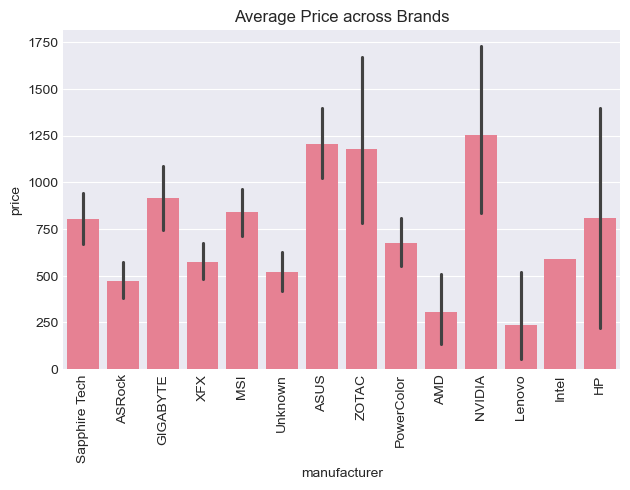

In [76]:
sns.barplot(data=df, x='manufacturer', y='price', estimator='mean')
plt.xticks(rotation=90)
plt.tight_layout()
plt.title('Average Price across Brands')
plt.show()

3. Memory Configuration Analysis
   - Distribution of memory sizes
   - Price correlation with memory size
   - Popular memory configurations by brand


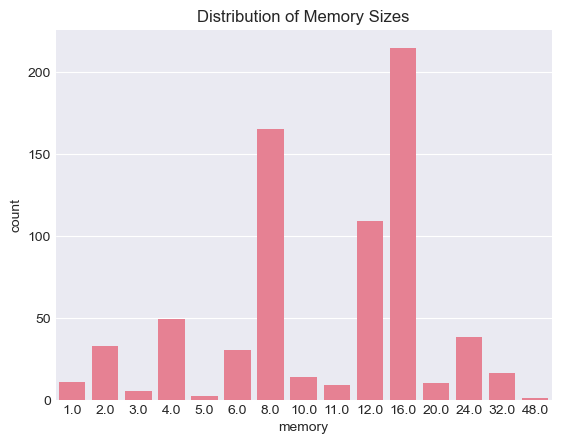

In [91]:
sns.countplot(data=df, x='memory')
plt.title('Distribution of Memory Sizes')
plt.show()

<Axes: xlabel='memory', ylabel='price'>

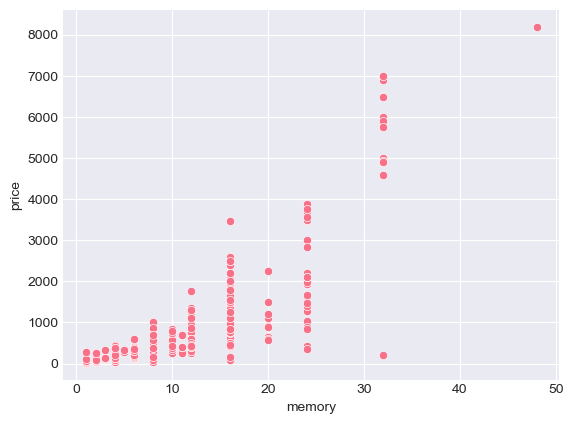

In [92]:
df[['memory','price']].corr()
sns.scatterplot(data=df, x='memory', y='price')

    manufacturer  memory  count
0            AMD     1.0      1
1            AMD     4.0      1
2            AMD     8.0      1
3            AMD    12.0      2
4            AMD    16.0      1
..           ...     ...    ...
98         ZOTAC    10.0      2
99         ZOTAC    12.0      6
100        ZOTAC    16.0      9
101        ZOTAC    24.0      3
102        ZOTAC    32.0      1

[103 rows x 3 columns]


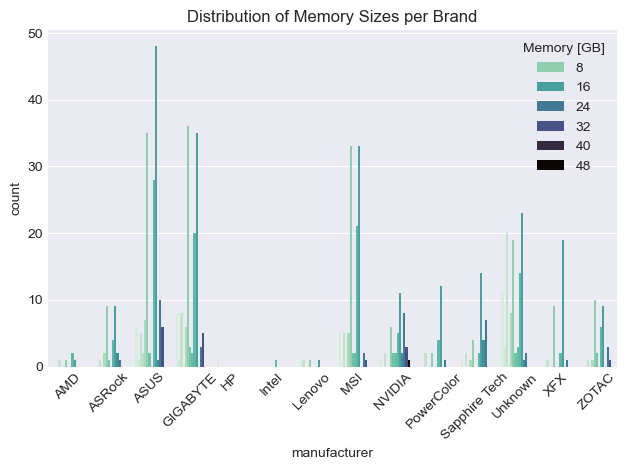

In [104]:
memory_dist = df.groupby(['manufacturer','memory']).size().reset_index(name='count')
print(memory_dist)

sns.barplot(data=memory_dist, x='manufacturer', y='count', hue='memory', palette='mako_r')
plt.title('Distribution of Memory Sizes per Brand')
plt.xticks(rotation=45)
plt.legend(title='Memory [GB]')
plt.tight_layout()
plt.show()

4. Market Segmentation
   - Entry-level vs Mid-range vs High-end segments
   - Price brackets and their features

In [114]:
def segment(price):
    if price < 250:
        return 'Entry-level'
    elif price < 500:
        return 'Mid-range'
    else:
        return 'High-end'

df['segment'] = df['price'].apply(segment)


In [119]:
df.describe()

,rating,reviews,price,shipping_price,original_price,memory,price_per_gb
count,719.000000,719.0,719.000000,719.000000,719.000000,707.000000,707.000000
mean,2.890264,76.589708,877.368067,1.529764,891.024715,11.961810,66.675237
std,2.214038,135.730131,988.387208,8.335028,986.620520,6.442376,37.258086
min,0.000000,0.0,18.740000,0.000000,18.740000,1.000000,4.156250
25%,0.000000,0.0,339.990000,0.000000,348.500000,8.000000,41.928854
50%,4.400000,5.0,590.000000,0.000000,599.000000,12.000000,60.382500
75%,4.700000,114.0,1006.235000,0.000000,1053.010000,16.000000,82.854167
max,5.000000,1504.0,8199.000000,60.000000,8199.000000,48.000000,289.000000


In [116]:
df['segment'].value_counts()

segment
High-end       418
Mid-range      183
Entry-level    118
Name: count, dtype: int64

Dividing the segment as <=250, <=500, > 500 would cause the High-end range to be disproportionately high. So we have to choose another segment division. Since the mean price per brand is known, we can use that as our reference points

In [129]:
def segment(price):
    if price < 400:
        return 'Entry-level'
    elif price < 1000:
        return 'Mid-range'
    else:
        return 'High-end'

df['segment'] = df['price'].apply(segment)


In [130]:
df['segment'].value_counts()

segment
Mid-range      310
Entry-level    227
High-end       182
Name: count, dtype: int64

A segment choice where mid-range is the mode should be suitable to represent normal distribution

In [131]:
df.groupby('segment')[['price','memory']].mean()
df.groupby('segment')['manufacturer'].value_counts()

segment      manufacturer 
Entry-level  Unknown          67
             ASUS             37
             GIGABYTE         37
             MSI              29
             ASRock           14
             NVIDIA           14
             Sapphire Tech     6
             XFX               6
             ZOTAC             6
             AMD               4
             Lenovo            4
             PowerColor        2
             HP                1
High-end     ASUS             61
             MSI              33
             GIGABYTE         32
             NVIDIA           16
             Unknown          14
             ZOTAC            11
             Sapphire Tech     8
             PowerColor        3
             ASRock            2
             HP                1
             XFX               1
Mid-range    GIGABYTE         60
             ASUS             54
             MSI              51
             Unknown          34
             XFX              26
             Sap